Viewing data

# Download the dataset


In [3]:
import numpy as np
from matplotlib import pyplot as plt

In [1]:
# https://drive.google.com/file/d/1CJyTqtCM4kOSQt2X7n2NgWCVEqou8RCB/view?usp=sharing
from google.colab import files
!gdown --id 1CJyTqtCM4kOSQt2X7n2NgWCVEqou8RCB


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1CJyTqtCM4kOSQt2X7n2NgWCVEqou8RCB
From (redirected): https://drive.google.com/uc?id=1CJyTqtCM4kOSQt2X7n2NgWCVEqou8RCB&confirm=t&uuid=0611e661-8131-4bdb-85bc-3ae3817c379f
To: /content/moving_target_dataset.npy
100% 1.52G/1.52G [00:35<00:00, 42.4MB/s]


# Print the classes in the dataset

In [8]:
filename = "moving_target_dataset.npy"
signatures = np.load(filename, allow_pickle=True)

class_names = []
for signature in signatures:
    if not any(signature['class_name'] in s for s in class_names):
        class_names.append(signature['class_name'])

print(class_names)

for signature in signatures:
  print(signature.keys())

['vehicle', 'person', 'bicycle', 'uav']
<built-in method keys of dict object at 0x7917c2759fc0>
<built-in method keys of dict object at 0x7917c1ba7d80>
<built-in method keys of dict object at 0x7917c1ba43c0>
<built-in method keys of dict object at 0x7917c1ba9e40>
<built-in method keys of dict object at 0x7917c2608180>
<built-in method keys of dict object at 0x7917c25c1d00>
<built-in method keys of dict object at 0x7917c3ac7000>
<built-in method keys of dict object at 0x7917c1bb4f40>
<built-in method keys of dict object at 0x7917c1bb4e00>
<built-in method keys of dict object at 0x7917c1bb5280>
<built-in method keys of dict object at 0x7917c1bb5180>
<built-in method keys of dict object at 0x7917c1bb4a00>
<built-in method keys of dict object at 0x7917c1bb5140>
<built-in method keys of dict object at 0x79177746c2c0>
<built-in method keys of dict object at 0x7917c1bab380>
<built-in method keys of dict object at 0x7917c2617300>
<built-in method keys of dict object at 0x7917c1bca5c0>
<built-i

# View the dataset
Shows some samples of the dataset

In [5]:
##%

is_shown = {}
for class_name in class_names:
    is_shown[class_name] = False

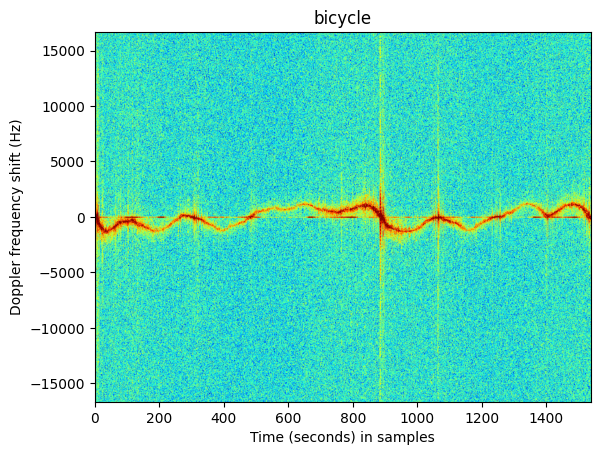

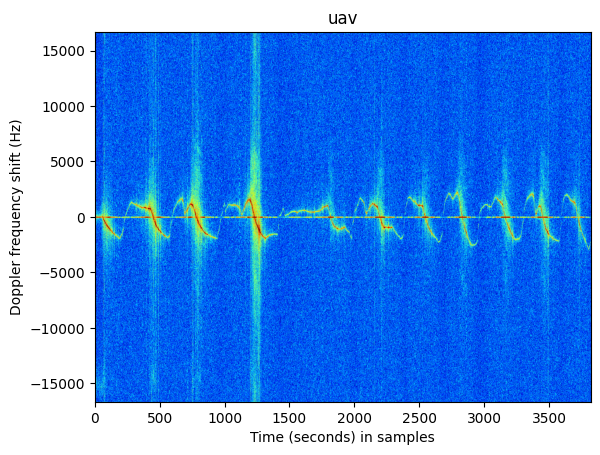

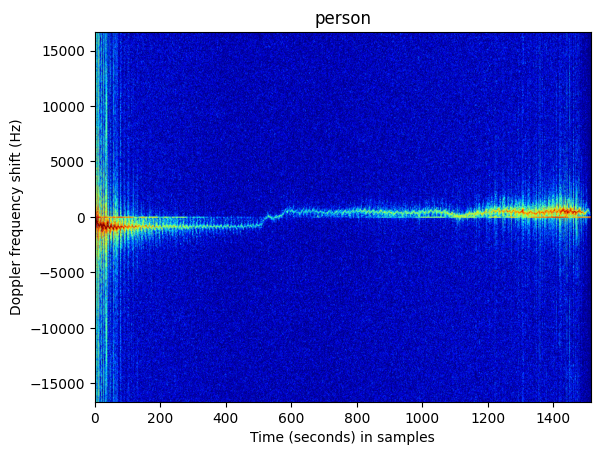

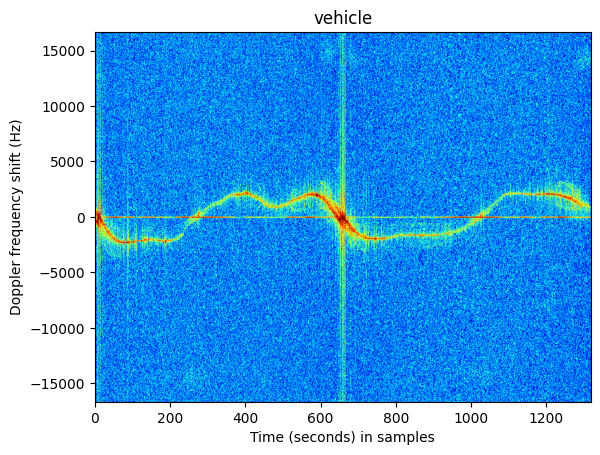

In [6]:
for signature in signatures:
    if (len(signature['snr_db']) > 500) or (signature['class_name']=="uav" and len(signature['snr_db']) > 100):
        if(not is_shown[signature['class_name']]):
            is_shown[signature['class_name']] = True
            arr = signature['signature']
            arr = 20 * np.log10(np.abs(arr)).transpose()
            prf = signature['radar_parameters']['prf']
            plt.imshow(arr, cmap='jet', aspect='auto', vmax=np.max(arr) - 20, vmin=np.max(arr) - 70,
                          extent=[0, arr.shape[1], -int(prf/2), int(prf / 2)])
            plt.title(signature['class_name'])
            plt.autoscale()
            # plt.colorbar(axdata)
            plt.xlabel('Time (seconds) in samples')
            plt.ylabel('Doppler frequency shift (Hz)')
            plt.show()

The files in the dataset are of long tracks of each subject, to use them for machine learning tests,
it is important that we split the the data on the track-basis an not only spectra.
We therefore perform the spliting at this point.

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn import preprocessing

all_indices = list(range(len(signatures)))
train_indices, test_indices = train_test_split(all_indices, test_size=0.2, random_state=42)

le = preprocessing.LabelEncoder()
le.fit_transform(class_names)

# for ind in train_indices:
train_signatures = [signatures[i] for i in train_indices]
test_signatures = [signatures[i] for i in test_indices]

#Count the Number of samples:
n_samples_train = 0
n_samples_test = 0
for signature in train_signatures:
    n_samples_train += len(signature['ts'])

for signature in test_signatures:
    n_samples_test += len(signature['ts'])


print("Train dataset size: " +str(n_samples_train))
print("Test dataset size: " +str(n_samples_test))


Train dataset size: 151455
Test dataset size: 35937


These two datasets now contain everything you need to do classification research.
You simply have to slice the spectrograms into convenient sizes and start the challenge.
Each spectra contains 1008 Doppler bins and concatinating 10 spectra corresponds to half a second observation time.
